### Image-to-Image Translation for Data Restoration


In observational astronomy, data is rarely perfect. Atmospheric seeing, instrumental noise, and optical aberrations (PSF) degrade our images. In this tutorial, we will train a Conditional Denoising Diffusion Probabilistic Model (DDPM) to learn the mapping from degraded observations back to crisp, clean galaxy images.

We will use the Galaxy10 SDSS dataset. To simulate telescope degradation, we will dynamically apply a Gaussian blur and inject noise into the clean images during training.

Our training objective updates to include the condition $c$:$$L = \mathbb{E}_{x_0, c, \epsilon, t} \left[ ||\epsilon - \epsilon_\theta(x_t, c, t)||^2 \right]$$


pip install astroNN h5py


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import math

def get_device():
    if torch.cuda.is_available(): return "cuda"
    elif torch.backends.mps.is_available(): return "mps"
    else: return "cpu"

device = get_device()
print(f"Using device: {device}")

Using device: cuda


### Simulating Telescope Degradation

To train a model to fix blurry images, we must first teach it what blurry images look like.

We load the standard 64x64 Galaxy10 SDSS images as our target "Ground Truth." Then, we create a PyTorch Dataset wrapper called DegradationWrapper. For every clean image, it dynamically applies a Gaussian blur and injects random sensor noise to create a realistic, corrupted observation. Our DataLoader will now yield pairs of (clean_galaxy, degraded_galaxy).


In [13]:
from astroNN.datasets import load_galaxy10sdss
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch

class Galaxy10SDSS(Dataset):
    """Downloads and wraps the Galaxy10 SDSS dataset for PyTorch."""
    def __init__(self, transform=None):
        # astroNN automatically downloads the 200MB .h5 file to ~/.astroNN/datasets/
        print("Loading Galaxy10 SDSS dataset...")
        images, labels = load_galaxy10sdss()
        
        # Images are returned as numpy arrays of shape (N, 69, 69, 3)
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

class DegradationWrapper(Dataset):
    """Wraps a dataset to return (clean_image, degraded_image) pairs."""
    def __init__(self, dataset):
        self.dataset = dataset
        # We use a Gaussian blur to simulate a telescope Point Spread Function (PSF)
        self.psf_blur = transforms.GaussianBlur(kernel_size=5, sigma=2.0)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # Extract the clean image (ignore the class label)
        clean_img, _ = self.dataset[idx]
        
        # Apply PSF Blur
        degraded_img = self.psf_blur(clean_img)
        
        # Add sensor noise
        noise = torch.randn_like(degraded_img) * 0.3
        degraded_img = torch.clamp(degraded_img + noise, -1.0, 1.0)
        
        return clean_img, degraded_img
    
# --- Pipeline Setup ---

# Galaxy10 images are 69x69. We center crop to 64x64 for the U-Net.
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scale to [-1, 1]
])

# 1. Load the base Galaxy10 dataset
base_dataset = Galaxy10SDSS(transform=transform)

# 2. Wrap it to generate our (Clean, Degraded) pairs for the Conditional DDPM
train_dataset = DegradationWrapper(base_dataset)

# 3. Create the DataLoader
dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)

print(f"Dataset ready! Total training pairs: {len(train_dataset)}")

Loading Galaxy10 SDSS dataset...
/home/xuduo/.astroNN/datasets/Galaxy10.h5 was found!
Dataset ready! Total training pairs: 21785


### Visualize a pair

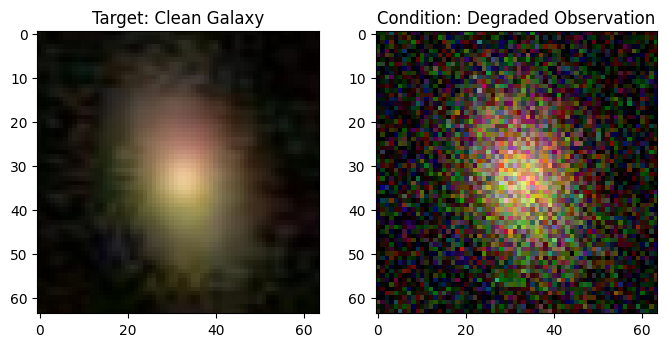

In [14]:
clean, degraded = train_dataset[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# Denormalize for viewing: (img * 0.5) + 0.5
axes[0].imshow((clean.permute(1, 2, 0).numpy() * 0.5) + 0.5)
axes[0].set_title("Target: Clean Galaxy")
axes[1].imshow((degraded.permute(1, 2, 0).numpy() * 0.5) + 0.5)
axes[1].set_title("Condition: Degraded Observation")
plt.show()

### The Forward Diffusion Process

Instead of using an external library for the noise scheduling (like diffusers in Demo 1), we are building the math explicitly. We define a linear variance schedule (betas) over 1000 timesteps. The extract function allows us to jump to any arbitrary point in the forward process to add the exact mathematical amount of noise needed for training.


In [15]:
# --- Diffusion Forward Process Parameters ---
T = 1000
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T).to(device)

alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

def extract(a, t, x_shape):
    """Extracts schedule values matching the batch timesteps."""
    batch_size = t.shape[0]
    # Removed .cpu() so both 'a' and 't' remain on the same device (GPU)
    out = a.gather(-1, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))


### The 6-Channel Conditional U-Net

This is the architectural core of Image-to-Image translation.

A standard U-Net takes a 3-channel RGB image. However, our model needs to look at both the noisy image state and the degraded observation simultaneously. We achieve this by concatenating them along the channel dimension.

Notice self.conv0: It is explicitly built to accept 6 input channels (3 noisy + 3 condition). We also inject Sinusoidal Time Embeddings into every ResNet block so the network knows how far along the denoising path it currently is.


In [16]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    """A standard ResNet-style block with Time Embedding injection."""
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
            
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.GroupNorm(8, out_ch)
        self.bnorm2 = nn.GroupNorm(8, out_ch)
        self.relu  = nn.SiLU()
        
    def forward(self, x, t):
        # First convolution
        h = self.bnorm1(self.relu(self.conv1(x)))
        # Inject time embedding
        time_emb = self.relu(self.time_mlp(t))
        # Extend time_emb spatial dimensions to match h
        time_emb = time_emb[(...,) + (None,) * 2]
        h = h + time_emb
        # Second convolution
        h = self.bnorm2(self.relu(self.conv2(h)))
        # Downsample or Upsample
        return self.transform(h)

class ConditionalUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256)
        up_channels = (256, 128, 64)
        out_dim = 3 
        time_emb_dim = 32

        # Time embedding layer
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )
        
        # IMPORTANT: Initial projection takes (3 noisy channels + 3 condition channels) = 6
        self.conv0 = nn.Conv2d(image_channels * 2, down_channels[0], 3, padding=1)

        # Downsample
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim) \
            for i in range(len(down_channels)-1)
        ])
        # Upsample
        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i+1], time_emb_dim, up=True) \
            for i in range(len(up_channels)-1)
        ])
        
        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x_t, condition, timestep):
        # 1. Embed time
        t = self.time_mlp(timestep)
        
        # 2. Concatenate noisy input and degraded condition
        x = torch.cat([x_t, condition], dim=1) 
        
        # 3. Initial convolution
        x = self.conv0(x)
        
        # 4. U-Net Pass
        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)
            
        for up in self.ups:
            residual_x = residual_inputs.pop()
            # Add skip connection
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)
            
        return self.output(x)

# Initialize the model
model = ConditionalUNet().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 3,693,731


### Robust Training Loop

Our training loop calculates the loss between the noise we actually added, and the noise the model predicts we added, given the blurry image as context.

We also include a robust check at the top of the cell. If a previously trained weights file is found, it automatically loads it to warm-start the training. This protects against kernel crashes or timeout limits on cluster environments.


In [17]:
import os

# --- SETUP AND TRAINING ---
model_save_path = "denoising_conditional_ddpm_galaxy10.pth"

# 1. Check if the model exists and load it to continue training
if os.path.exists(model_save_path):
    print(f"Found existing model at '{model_save_path}'. Loading weights to continue training...")
    model.load_state_dict(torch.load(model_save_path, map_location=device,weights_only=True))
else:
    print(f"No existing model found at '{model_save_path}'. Starting training from scratch...")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 1 # Set higher for actual training (e.g., 50)

print("\nStarting Training Loop...")
for epoch in range(epochs):
    epoch_loss = 0
    model.train()
    
    num_iterations = len(dataloader) 
    
    for i, (clean_img, degraded_img) in enumerate(dataloader):
        clean_img, degraded_img = clean_img.to(device), degraded_img.to(device)
        batch_size = clean_img.shape[0]
        
        # Sample random timesteps
        t = torch.randint(0, T, (batch_size,), device=device).long()
        
        # Generate noise and apply it to the clean image
        noise = torch.randn_like(clean_img)
        sqrt_alpha_t = extract(sqrt_alphas_cumprod, t, clean_img.shape)
        sqrt_one_minus_alpha_t = extract(sqrt_one_minus_alphas_cumprod, t, clean_img.shape)
        x_t = sqrt_alpha_t * clean_img + sqrt_one_minus_alpha_t * noise
        
        # Predict noise using the condition
        predicted_noise = model(x_t, degraded_img, t)
        loss = F.mse_loss(predicted_noise, noise)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
        # # Print progress every 50 iterations
        if (i + 1) % 50 == 0:
            print(f"  Iteration {i+1}/{num_iterations} | Current Batch Loss: {loss.item():.4f}")
        
    avg_epoch_loss = epoch_loss / num_iterations
    print(f"Epoch {epoch+1:03d}/{epochs} Completed | Average Loss: {avg_epoch_loss:.4f}")
    
    # Optional: Save at the end of each epoch to be safe, 
    # overwriting the same file to keep the directory clean.
    torch.save(model.state_dict(), model_save_path)

print(f"\n✅ Training complete! Final weights saved to '{model_save_path}'")



Found existing model at 'denoising_conditional_ddpm_galaxy10.pth'. Loading weights to continue training...

Starting Training Loop...


  Iteration 50/341 | Current Batch Loss: 0.0040
  Iteration 100/341 | Current Batch Loss: 0.0051
  Iteration 150/341 | Current Batch Loss: 0.0072
  Iteration 200/341 | Current Batch Loss: 0.0027
  Iteration 250/341 | Current Batch Loss: 0.0177
  Iteration 300/341 | Current Batch Loss: 0.0069
Epoch 001/1 Completed | Average Loss: 0.0068

✅ Training complete! Final weights saved to 'denoising_conditional_ddpm_galaxy10.pth'


### Denoising Inference

To restore a corrupted galaxy image, we initialize a tensor of pure Gaussian noise. We feed this noise into the U-Net alongside our real degraded observation.

Over 1000 steps, the model iteratively subtracts noise. Because the degraded image is acting as an anchor at every single step, the model is physically constrained to rebuild a clean galaxy that perfectly matches the blurry input.


Starting conditional sampling (this takes a moment)...


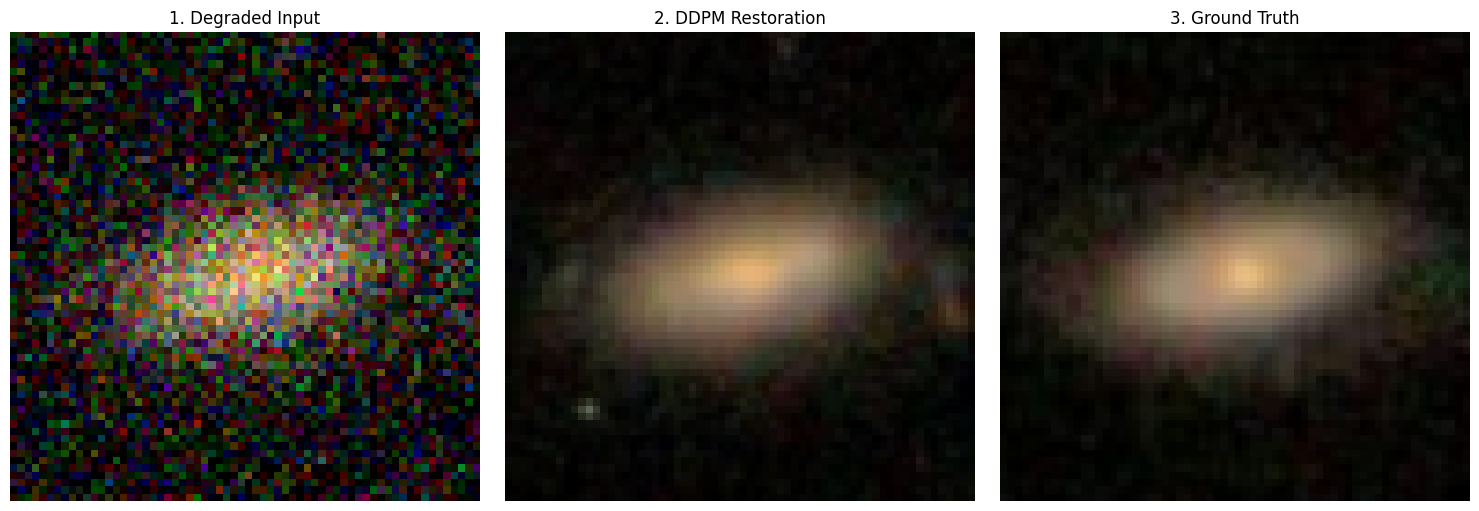

In [18]:

# ==========================================
# --- LOADING AND SAMPLING DEMONSTRATION ---
# ==========================================

@torch.no_grad()
def restore_galaxy(model, degraded_observation):
    model.eval()
    batch_size = degraded_observation.shape[0]
    shape = degraded_observation.shape
    
    # Start from pure noise
    x_t = torch.randn(shape, device=device)
    
    for i in reversed(range(0, T)):
        t = torch.full((batch_size,), i, device=device, dtype=torch.long)
        
        predicted_noise = model(x_t, degraded_observation, t)
        
        alpha_t = extract(alphas, t, x_t.shape)
        alpha_cumprod_t = extract(alphas_cumprod, t, x_t.shape)
        beta_t = extract(betas, t, x_t.shape)
        
        noise = torch.randn_like(x_t) if i > 0 else torch.zeros_like(x_t)
            
        x_t = (1 / torch.sqrt(alpha_t)) * (
            x_t - ((1 - alpha_t) / (torch.sqrt(1 - alpha_cumprod_t))) * predicted_noise
        ) + torch.sqrt(beta_t) * noise
        
    return x_t

# Grab a batch for testing
clean_imgs, degraded_imgs = next(iter(dataloader))
degraded_imgs = degraded_imgs.to(device)

print("\nStarting conditional sampling (this takes a moment)...")
restored_imgs = restore_galaxy(model, degraded_imgs)

# Plotting the result
idx = 0
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def show_tensor(tensor, ax, title):
    img = (tensor[idx].cpu().permute(1, 2, 0).numpy() * 0.5) + 0.5
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(title)
    ax.axis('off')

show_tensor(degraded_imgs, axes[0], "1. Degraded Input")
show_tensor(restored_imgs, axes[1], "2. DDPM Restoration")
show_tensor(clean_imgs, axes[2], "3. Ground Truth")
plt.tight_layout()
plt.show()

### Quantifying Restoration: PSNR and SSIM

For Image-to-Image translation and denoising tasks, we evaluate our model by comparing the restored output directly against the clean ground truth, pixel-by-pixel and structure-by-structure. To do this, we use two standard signal processing metrics:

#### 1. Peak Signal-to-Noise Ratio (PSNR)
PSNR measures the absolute pixel-level error between the restored image and the clean image, heavily penalizing large deviations (like hallucinated bright spots). It is expressed in decibels (dB).
$$\text{PSNR} = 10 \cdot \log_{10} \left( \frac{\text{MAX}^2}{\text{MSE}} \right)$$

MAX: The maximum possible pixel value (e.g., 1.0 for normalized floats).

MSE: The Mean Squared Error between the predicted and target images.

Interpretation: Higher is better. A PSNR above 30 dB is generally considered good quality.

#### 2. Structural Similarity Index (SSIM)
While PSNR measures the absolute pixel-by-pixel error, it is famously bad at mimicking human perception. If our DDPM perfectly restores the shape of a spiral galaxy but shifts the entire image by just one pixel to the left, the MSE skyrockets and the PSNR score will look terrible.

The Structural Similarity Index Measure (SSIM) fixes this. Instead of treating an image as a grid of independent pixels, SSIM evaluates the image based on three things our eyes naturally look for: Luminance, Contrast, and Structure.

$$\text{SSIM}(x, y) = \frac{(2\mu_x\mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)}$$

SSIM is not calculated on the whole image at once. It slides a small "window" (usually $11 \times 11$ pixels) across the image, calculating this equation for every patch, and averages the results.

$x$ and $y$: The two image patches being compared (e.g., the Ground Truth galaxy and our DDPM Restored galaxy).

$\mu_x$ and $\mu_y$: The average pixel intensities (means) of patches $x$ and $y$.

$\sigma_x^2$ and $\sigma_y^2$: The variance of pixel intensities in patches $x$ and $y$.

$\sigma_{xy}$: The covariance between patches $x$ and $y$.

$c_1$ and $c_2$: Small constants added to the numerator and denominator. Space is mostly dark; if we compare two patches of empty black background, the means and variances will be near zero. These constants prevent the formula from throwing a "divide by zero" mathematical error.

##### How the Formula works 

The equation above is actually a clever mathematical simplification of three separate comparisons multiplied together:

Luminance (Brightness): The first term $\frac{2\mu_x\mu_y + c_1}{\mu_x^2 + \mu_y^2 + c_1}$ compares the average brightness of the two patches. If our DDPM restores the galaxy but makes it 50% darker, this term drops.

Contrast: Measured using the variances ($\sigma_x^2$ and $\sigma_y^2$). Does the restored galaxy have the same dynamic range between its bright core and faint spiral arms as the real galaxy?

Structure: Measured using the covariance ($\sigma_{xy}$). This is the most important part. Covariance measures correlation: if a pixel is bright in the real galaxy, is it also bright in the restored galaxy? This effectively checks if the edges, shapes, and features align, regardless of their absolute brightness.


By multiplying these components together, SSIM outputs a final score between $-1$ and $1$. A score of $1.0$ means the two images share perfect structural identity. For astronomy, SSIM is the ultimate test of whether our diffusion model hallucinated fake structures or genuinely removed the noise to reveal the true physics beneath.


In [19]:
import torch
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

print("Initializing PSNR and SSIM Metrics...")

# We un-normalize our images from [-1, 1] to [0, 1] for standard metric calculation
def unnormalize(tensor):
    return torch.clamp((tensor + 1.0) / 2.0, 0.0, 1.0)

# CRITICAL FIX: Ensure all tensors are pushed to the same device (GPU)
clean_01 = unnormalize(clean_imgs.to(device))
degraded_01 = unnormalize(degraded_imgs.to(device))
restored_01 = unnormalize(restored_imgs.to(device))

# Initialize metrics (data_range is 1.0 since our pixels are now between 0 and 1)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

# --- 1. Calculate Baseline (How bad was the degraded image?) ---
print("\nCalculating Baseline (Degraded vs. Ground Truth)...")
baseline_psnr = psnr_metric(degraded_01, clean_01)
baseline_ssim = ssim_metric(degraded_01, clean_01)

# --- 2. Calculate DDPM Performance (How good is our restoration?) ---
print("Calculating DDPM Restoration (Restored vs. Ground Truth)...")
# Reset metrics just to be safe
psnr_metric.reset()
ssim_metric.reset()

restored_psnr = psnr_metric(restored_01, clean_01)
restored_ssim = ssim_metric(restored_01, clean_01)

# --- 3. Display Results ---
print("\n" + "="*40)
print("📊 RESTORATION METRICS REPORT")
print("="*40)

print(f"PSNR (Higher is Better):")
print(f"  Baseline (Degraded):  {baseline_psnr.item():.2f} dB")
print(f"  DDPM Restored:        {restored_psnr.item():.2f} dB")
print(f"  Improvement:          +{restored_psnr.item() - baseline_psnr.item():.2f} dB\n")

print(f"SSIM (Closer to 1.0 is Better):")
print(f"  Baseline (Degraded):  {baseline_ssim.item():.4f}")
print(f"  DDPM Restored:        {restored_ssim.item():.4f}")
print(f"  Improvement:          +{restored_ssim.item() - baseline_ssim.item():.4f}")
print("="*40)

Initializing PSNR and SSIM Metrics...

Calculating Baseline (Degraded vs. Ground Truth)...
Calculating DDPM Restoration (Restored vs. Ground Truth)...

📊 RESTORATION METRICS REPORT
PSNR (Higher is Better):
  Baseline (Degraded):  18.55 dB
  DDPM Restored:        30.86 dB
  Improvement:          +12.31 dB

SSIM (Closer to 1.0 is Better):
  Baseline (Degraded):  0.1093
  DDPM Restored:        0.7111
  Improvement:          +0.6018
